# Pandas vs. GeoPandas vs. shapely 
- Pandas - https://pandas.pydata.org/

    - Praca z danymi tabelarycznymi (wiersze–kolumny), bez pojęcia geometrii.
    - Używany do: wczytywania CSV, czyszczenia danych, analizy danych, groupby, merge, statystyk, tabel atrybutów.

- GeoPandas - https://geopandas.org/en/stable/index.html

    - Rozszerza pandas o kolumnę geometry z obiektami Shapely + obsługa CRS (układów współrzędnych).
    - Używany do: pracy z warstwami GIS (gminy, drogi, budynki), wczytywania SHP/GPKG/GML/WFS, filtrowania przestrzennego i atrybutowego, overlay, sjoin, buffer dla całych warstw, liczenia długości/powierzchni i rysowania map.

- shapely - https://shapely.readthedocs.io/en/stable/index.html

    - Operacje na pojedynczych geometriach (punkt, linia, poligon).
    - Używany do: tworzenia kształtów (Point, LineString, Polygon, box), obliczeń geometrycznych (buffer, intersection, distance) dla pojedynczych obiektów.


# Wprowadzenie do GeoPandas na przykładzie granic administracyjnych

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

### Wczytanie danych i wyświetlenie atrybutów

In [2]:
path_gminy = "01_dane/A03_Granice_gmin.gml"
# można wyczytywać różne rozszerzenia danych, które zwierają geometrię: shp, gpkg, gml, xml...

gminy = gpd.read_file(path_gminy)  # tworzenie geodataframe
gminy.head()  # wyświetlenie kilku pierwszych wierszy danych

,gml_id,JPT_SJR_KO,JPT_POWIER,JPT_KOD_JE,JPT_NAZWA_,JPT_JOR_ID,WERSJA_OD,WAZNY_OD,JPT_ORGAN1,JPT_WAZNA_,IIP_PRZEST,IIP_IDENTY,IIP_WERSJA,JPT_KJ_IIP,JPT_KJ_I_1,JPT_SPS_KO,JPT_ID,REGON,geometry
0,idafea519e-1489-4be2-a60c-cdd2b596a719,GMI,9825,1205023,Biecz,13136,2025-03-31T13:29:18,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,35cb867e-2060-48db-86f0-f5698bf4617f,2025-03-31T13:29:18,EGIB,1205023.0,UZG,2760620,37044061400000,"MULTIPOLYGON (((660361.45 206718.58, 660354.82..."
1,idb8320d25-dfce-40f4-98dc-b6c9e479f458,GMI,7207,1206072,Liszki,13136,2025-06-03T13:08:59,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,8970b0e9-429b-4e7b-81af-b0ccc0bcb2b2,2025-06-03T13:08:59,EGIB,1206072.0,UZG,2772534,35155574300000,"MULTIPOLYGON (((552528.99 246396.88, 552508.88..."
2,id512af603-746c-49b7-8795-0f6e935e3514,GMI,11644,1204023,Dąbrowa Tarnowska,13136,2025-01-14T00:00:00,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,d4aeac5b-11cd-4516-b951-fecaec684dcf,2025-01-14T00:00:00,EGIB,1204023.0,UZG,2753803,85166114500000,"MULTIPOLYGON (((643370.77 252957.12, 643387.97..."
3,id534632ba-1548-45fd-95e8-e0b8dbac8519,GMI,8053,1215042,Bystra-Sidzina,13136,2025-01-27T14:50:47,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,d2943281-c5be-4963-8ad9-aaf2a3147814,2025-01-27T14:50:47,EGIB,1215042.0,UZG,2757448,49189209600000,"MULTIPOLYGON (((554248.86 194854.79, 554257.19..."
4,idbfc49ab8-7c9a-47f4-86c2-61f8e2d149e7,GMI,5911,1208062,Racławice,13136,2025-05-09T12:59:03,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,21b146b2-8882-4eab-830f-e12648d382c0,2025-05-09T12:59:03,EGIB,1208062.0,UZG,2767769,29101061300000,"MULTIPOLYGON (((592102.06 273202.63, 592050.06..."


wyświetlanie informacji o pliku i metadanych 

In [3]:
gminy.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   gml_id      183 non-null    str     
 1   JPT_SJR_KO  183 non-null    str     
 2   JPT_POWIER  183 non-null    int32   
 3   JPT_KOD_JE  183 non-null    int32   
 4   JPT_NAZWA_  183 non-null    str     
 5   JPT_JOR_ID  183 non-null    int32   
 6   WERSJA_OD   183 non-null    str     
 7   WAZNY_OD    183 non-null    str     
 8   JPT_ORGAN1  183 non-null    str     
 9   JPT_WAZNA_  183 non-null    str     
 10  IIP_PRZEST  183 non-null    str     
 11  IIP_IDENTY  183 non-null    str     
 12  IIP_WERSJA  183 non-null    str     
 13  JPT_KJ_IIP  183 non-null    str     
 14  JPT_KJ_I_1  182 non-null    float64 
 15  JPT_SPS_KO  183 non-null    str     
 16  JPT_ID      183 non-null    int32   
 17  REGON       183 non-null    str     
 18  geometry    183 non-null    geometry
dtype

In [4]:
gminy.columns

Index(['gml_id', 'JPT_SJR_KO', 'JPT_POWIER', 'JPT_KOD_JE', 'JPT_NAZWA_',
       'JPT_JOR_ID', 'WERSJA_OD', 'WAZNY_OD', 'JPT_ORGAN1', 'JPT_WAZNA_',
       'IIP_PRZEST', 'IIP_IDENTY', 'IIP_WERSJA', 'JPT_KJ_IIP', 'JPT_KJ_I_1',
       'JPT_SPS_KO', 'JPT_ID', 'REGON', 'geometry'],
      dtype='str')

In [5]:
gminy.crs

<Projected CRS: EPSG:2180>
Name: ETRF2000-PL / CS92
Axis Info [cartesian]:
- x[north]: Northing (metre)
- y[east]: Easting (metre)
Area of Use:
- name: Poland - onshore and offshore.
- bounds: (14.14, 49.0, 24.15, 55.93)
Coordinate Operation:
- name: Poland CS92
- method: Transverse Mercator
Datum: ETRF2000 Poland
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [6]:
gminy.geom_type.value_counts()

MultiPolygon    183
Name: count, dtype: int64

wybór kolumny lub komórki 

In [7]:
# wyświetla nazwy gmin 
gminy["JPT_NAZWA_"]

# robi listę nazw gmin
gminy["JPT_NAZWA_"].to_list()

# wybiera jedną gminę (wiersz z dataframe) po nazwie 
nazwa_gminy = "Kraków"
gmina_sel = gminy[gminy["JPT_NAZWA_"] == nazwa_gminy]
gmina_sel

,gml_id,JPT_SJR_KO,JPT_POWIER,JPT_KOD_JE,JPT_NAZWA_,JPT_JOR_ID,WERSJA_OD,WAZNY_OD,JPT_ORGAN1,JPT_WAZNA_,IIP_PRZEST,IIP_IDENTY,IIP_WERSJA,JPT_KJ_IIP,JPT_KJ_I_1,JPT_SPS_KO,JPT_ID,REGON,geometry
25,id6ffdb62c-b44b-482f-afd1-bc9da3623a6e,GMI,32687,1261011,Kraków,13136,2026-02-24T10:28:06,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,e148d7e5-6202-4e1a-9503-fe34bbf9bf45,2026-02-24T10:28:06,EGIB,1261011.0,UZG,10012000,35155435300000,"MULTIPOLYGON (((567875.13 234308.35, 567885.86..."


### Prosta wizualizacja gmin

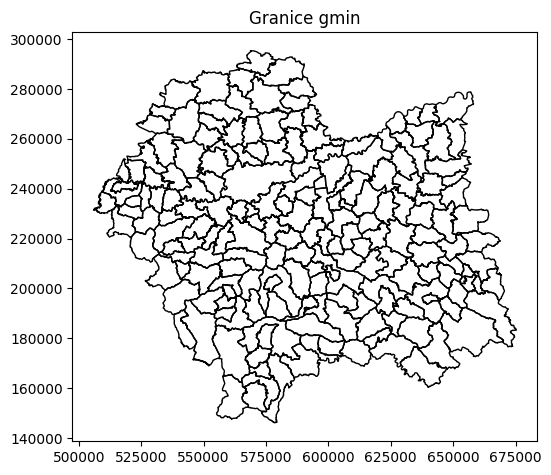

In [8]:
# rysowanie mapki gmin 

ax = gminy.plot(edgecolor="black", facecolor="none", figsize=(6, 6))
ax.set_title("Granice gmin")
plt.show()

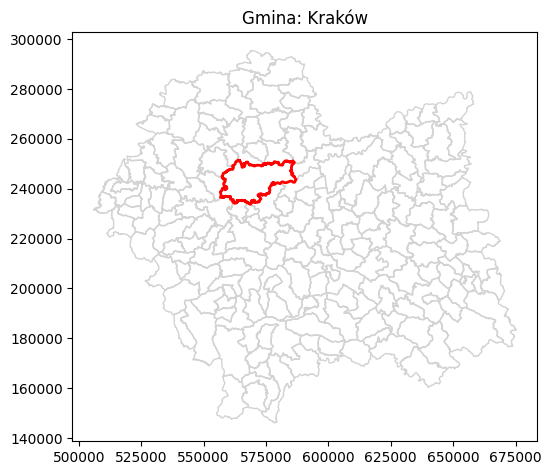

In [9]:
# rysowanie wybranej gminy na tle mapy 

ax = gminy.plot(edgecolor="lightgray", facecolor="none", figsize=(6, 6))
gmina_sel.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=2)
ax.set_title(f"Gmina: {nazwa_gminy}")
plt.show()

### Atrybuty goemetryczne - przeliczanie powierzchni 

In [10]:
# pole powierzchni wybranej gminy (w metrach kwadratowych)
area = gmina_sel.geometry.area
print(type(area))
print(area)

# przekształcenie powierzchni w liczbę
area_m2 = area.iloc[0]  # wyciągnięcie liczby z Series
print(type(area_m2))
print(area_m2)
area_km2 = area_m2 / 1000000  # przeliczenie m² -> km²
print(area_km2)

<class 'pandas.Series'>
25    3.264503e+08
dtype: float64
<class 'numpy.float64'>
326450298.46135044
326.4502984613504


In [11]:
# dodanie pola powierzchni jako kolumny do całej serii danych 
gminy["area_m2"] = gminy.geometry.area
gminy["area_km2"] = gminy["area_m2"] / 1000000

gminy.head()
# gdy chcemy wyświetlić tylko nazwę i powierzchnię 
#gminy[["JPT_NAZWA_", "area_km2"]].head() 

,gml_id,JPT_SJR_KO,JPT_POWIER,JPT_KOD_JE,JPT_NAZWA_,JPT_JOR_ID,WERSJA_OD,WAZNY_OD,JPT_ORGAN1,JPT_WAZNA_,...,IIP_IDENTY,IIP_WERSJA,JPT_KJ_IIP,JPT_KJ_I_1,JPT_SPS_KO,JPT_ID,REGON,geometry,area_m2,area_km2
0,idafea519e-1489-4be2-a60c-cdd2b596a719,GMI,9825,1205023,Biecz,13136,2025-03-31T13:29:18,2012-09-26T00:00:00,NZN,NZN,...,35cb867e-2060-48db-86f0-f5698bf4617f,2025-03-31T13:29:18,EGIB,1205023.0,UZG,2760620,37044061400000,"MULTIPOLYGON (((660361.45 206718.58, 660354.82...",9.817441e+07,98.174406
1,idb8320d25-dfce-40f4-98dc-b6c9e479f458,GMI,7207,1206072,Liszki,13136,2025-06-03T13:08:59,2012-09-26T00:00:00,NZN,NZN,...,8970b0e9-429b-4e7b-81af-b0ccc0bcb2b2,2025-06-03T13:08:59,EGIB,1206072.0,UZG,2772534,35155574300000,"MULTIPOLYGON (((552528.99 246396.88, 552508.88...",7.197329e+07,71.973291
2,id512af603-746c-49b7-8795-0f6e935e3514,GMI,11644,1204023,Dąbrowa Tarnowska,13136,2025-01-14T00:00:00,2012-09-26T00:00:00,NZN,NZN,...,d4aeac5b-11cd-4516-b951-fecaec684dcf,2025-01-14T00:00:00,EGIB,1204023.0,UZG,2753803,85166114500000,"MULTIPOLYGON (((643370.77 252957.12, 643387.97...",1.163364e+08,116.336429
3,id534632ba-1548-45fd-95e8-e0b8dbac8519,GMI,8053,1215042,Bystra-Sidzina,13136,2025-01-27T14:50:47,2012-09-26T00:00:00,NZN,NZN,...,d2943281-c5be-4963-8ad9-aaf2a3147814,2025-01-27T14:50:47,EGIB,1215042.0,UZG,2757448,49189209600000,"MULTIPOLYGON (((554248.86 194854.79, 554257.19...",8.041821e+07,80.418210
4,idbfc49ab8-7c9a-47f4-86c2-61f8e2d149e7,GMI,5911,1208062,Racławice,13136,2025-05-09T12:59:03,2012-09-26T00:00:00,NZN,NZN,...,21b146b2-8882-4eab-830f-e12648d382c0,2025-05-09T12:59:03,EGIB,1208062.0,UZG,2767769,29101061300000,"MULTIPOLYGON (((592102.06 273202.63, 592050.06...",5.903461e+07,59.034613


### Atrybuty goemetryczne - BBOX
tworzenie boundry box na podstawie jednej komórki 

In [12]:
bbox = gmina_sel.total_bounds
print(bbox)

[556734.83 233811.93 587119.64 251374.53]


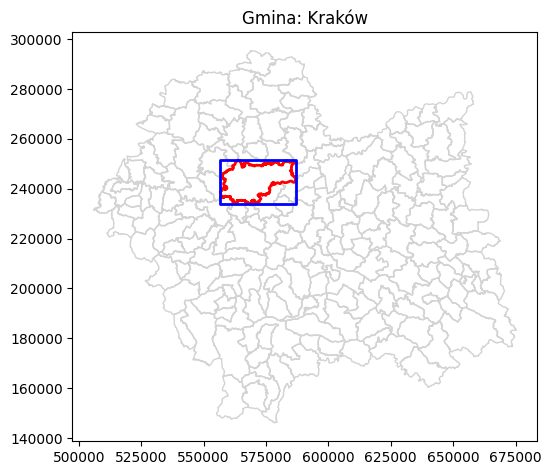

In [13]:
from shapely.geometry import box

# obliczanie granic boxa 
minx, miny, maxx, maxy = gmina_sel.total_bounds

# robienie obiektu typu poligon za pomocą metody box z modułu shapely.geometry
bbox_geom = box(minx, miny, maxx, maxy)

# tworzenie geodataframe z poligonu 
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_geom], crs=gmina_sel.crs)

ax = gminy.plot(edgecolor="lightgray", facecolor="none", figsize=(6, 6))
gmina_sel.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=2)
bbox_gdf.plot(ax=ax, edgecolor="blue", facecolor="none", linewidth=2)
ax.set_title(f"Gmina: {nazwa_gminy}")
plt.show()

### Zadanie

1. Wczytaj plik z granicami powiatów dla wojewodztwa małopolskiego. 
2. Sprawdź w jakim są układzie współrzędnych. 
3. Wyciągnij informację o liczbie powiatów. 
4. Oblicz powierzchnię powiatów w km2 i dodaj te wartości jako nową kolumnę. 
5. Oblicz sumę powierzchni wszystkich powiatów. 
6. Przdstaw na mapie powiaty województwa małopolskiego w różnych kolorach. Spróbuj przedstawić kolory wg powierzchni powiatu (czyli np najmniejsze najjaśniejszy niebieski, a największe najciemniejszy).

In [14]:
powiaty = "01_dane/A02_Granice_powiatow.gml"
powiaty = gpd.read_file(powiaty)
powiaty.head()

,gml_id,JPT_SJR_KO,JPT_POWIER,JPT_KOD_JE,JPT_NAZWA_,JPT_JOR_ID,WERSJA_OD,WAZNY_OD,JPT_ORGAN1,JPT_WAZNA_,IIP_PRZEST,IIP_IDENTY,IIP_WERSJA,JPT_KJ_IIP,JPT_KJ_I_1,JPT_SPS_KO,JPT_ID,REGON,geometry
0,id03207e54-7d1c-40d1-9120-f88857f81abb,POW,64872,1201,powiat bocheński,13136,2026-02-24T10:28:06,2024-02-21T00:00:00,NZN,NZN,PL.PZGIK.200,9ae62200-8233-49ef-aec3-b3c95fa6127e,2026-02-24T10:28:06,EGIB,1201.0,UZG,10012122,85166056500000,"MULTIPOLYGON (((601138.34 253334.41, 601132.22..."
1,ideb1ce3ff-b0f4-43dc-961b-c318f54be2fc,POW,59064,1202,powiat brzeski,13136,2025-05-09T12:59:04,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,8d0b0a85-17f0-4358-98a4-d312d6212b93,2025-05-09T12:59:04,EGIB,1202.0,UZG,2768236,53141244400000,"MULTIPOLYGON (((623158.98 221253.6, 623163.25 ..."
2,id138f509f-f014-439e-a30b-2b8cdb68780f,POW,36995,1203,powiat chrzanowski,13136,2026-02-24T10:28:07,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,8eaf0bfb-3bf3-40dd-a6bb-f5afb0a466c6,2026-02-24T10:28:07,EGIB,1203.0,UZG,10012155,27625497900000,"MULTIPOLYGON (((537478.54 259410.45, 537499.73..."
3,idf51e06b9-b8af-4ad9-be7a-e6cca6031317,POW,53023,1204,powiat dąbrowski,13136,2025-10-17T08:06:51,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,2f8e6930-0088-406e-b684-cebb73fc5bd9,2025-10-17T08:06:51,EGIB,1204.0,UZG,2785514,85166041800000,"MULTIPOLYGON (((654969.49 258855.55, 654960.29..."
4,id94816bc9-034f-4fdb-8fe5-67451d3ca567,POW,96630,1205,powiat gorlicki,13136,2025-03-31T13:29:18,2012-09-26T00:00:00,NZN,BRK,PL.PZGIK.200,5b376d4f-e6fb-48f4-9302-a9b0a6cc2aeb,2025-03-31T13:29:18,EGIB,1205.0,UZG,2760311,49189315000000,"MULTIPOLYGON (((657657.55 173841.32, 657695.98..."


In [15]:
powiaty.crs

<Projected CRS: EPSG:2180>
Name: ETRF2000-PL / CS92
Axis Info [cartesian]:
- x[north]: Northing (metre)
- y[east]: Easting (metre)
Area of Use:
- name: Poland - onshore and offshore.
- bounds: (14.14, 49.0, 24.15, 55.93)
Coordinate Operation:
- name: Poland CS92
- method: Transverse Mercator
Datum: ETRF2000 Poland
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [16]:
powiaty.geom_type.value_counts()

MultiPolygon    22
Name: count, dtype: int64

In [17]:
powiaty["area_km2"] = powiaty.geometry.area / 1000000
powiaty.head()

,gml_id,JPT_SJR_KO,JPT_POWIER,JPT_KOD_JE,JPT_NAZWA_,JPT_JOR_ID,WERSJA_OD,WAZNY_OD,JPT_ORGAN1,JPT_WAZNA_,IIP_PRZEST,IIP_IDENTY,IIP_WERSJA,JPT_KJ_IIP,JPT_KJ_I_1,JPT_SPS_KO,JPT_ID,REGON,geometry,area_km2
0,id03207e54-7d1c-40d1-9120-f88857f81abb,POW,64872,1201,powiat bocheński,13136,2026-02-24T10:28:06,2024-02-21T00:00:00,NZN,NZN,PL.PZGIK.200,9ae62200-8233-49ef-aec3-b3c95fa6127e,2026-02-24T10:28:06,EGIB,1201.0,UZG,10012122,85166056500000,"MULTIPOLYGON (((601138.34 253334.41, 601132.22...",647.979559
1,ideb1ce3ff-b0f4-43dc-961b-c318f54be2fc,POW,59064,1202,powiat brzeski,13136,2025-05-09T12:59:04,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,8d0b0a85-17f0-4358-98a4-d312d6212b93,2025-05-09T12:59:04,EGIB,1202.0,UZG,2768236,53141244400000,"MULTIPOLYGON (((623158.98 221253.6, 623163.25 ...",590.017024
2,id138f509f-f014-439e-a30b-2b8cdb68780f,POW,36995,1203,powiat chrzanowski,13136,2026-02-24T10:28:07,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,8eaf0bfb-3bf3-40dd-a6bb-f5afb0a466c6,2026-02-24T10:28:07,EGIB,1203.0,UZG,10012155,27625497900000,"MULTIPOLYGON (((537478.54 259410.45, 537499.73...",369.436875
3,idf51e06b9-b8af-4ad9-be7a-e6cca6031317,POW,53023,1204,powiat dąbrowski,13136,2025-10-17T08:06:51,2012-09-26T00:00:00,NZN,NZN,PL.PZGIK.200,2f8e6930-0088-406e-b684-cebb73fc5bd9,2025-10-17T08:06:51,EGIB,1204.0,UZG,2785514,85166041800000,"MULTIPOLYGON (((654969.49 258855.55, 654960.29...",529.755342
4,id94816bc9-034f-4fdb-8fe5-67451d3ca567,POW,96630,1205,powiat gorlicki,13136,2025-03-31T13:29:18,2012-09-26T00:00:00,NZN,BRK,PL.PZGIK.200,5b376d4f-e6fb-48f4-9302-a9b0a6cc2aeb,2025-03-31T13:29:18,EGIB,1205.0,UZG,2760311,49189315000000,"MULTIPOLYGON (((657657.55 173841.32, 657695.98...",965.530883


In [18]:
int(powiaty["area_km2"].sum())

15166

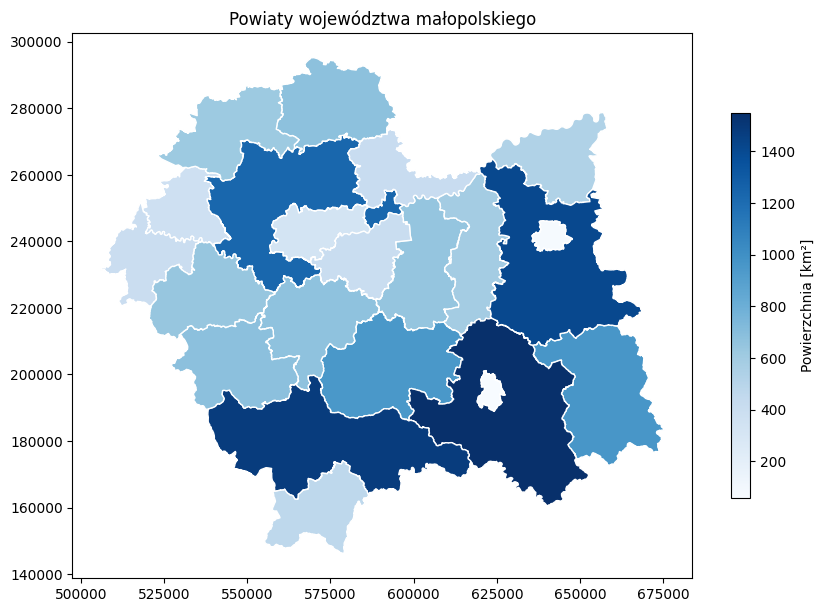

In [19]:
fig, ax = plt.subplots(figsize=(10, 10))
powiaty.plot(
    column="area_km2",
    cmap="Blues",
    edgecolor="white",
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "Powierzchnia [km²]",
        "shrink": 0.5
    }
)
ax.set_title("Powiaty województwa małopolskiego")
plt.show()